# PRG Toolbox Tutorial: The Contact Process Model

This notebook provides a practical demonstration of how to use the Phenomenological Renormalization Group (PRG) toolbox. 

To illustrate the PRG pipeline, we will analyze synthetic data generated by the **Contact Process model**. The Contact Process is a fundamental spatial spreading model belonging to the directed percolation universality class. It is characterized by a continuous, second-order phase transition that separates a macroscopic active state from an absorbing (completely inactive) state. 

---

### Simulation Code Credits
The Contact Process simulation code used to generate the dataset in this notebook was originally developed for the research presented in [Phys. Rev. Research 2, 023144 (2020)](https://journals.aps.org/prresearch/abstract/10.1103/PhysRevResearch.2.023144). 

If you use any part of the simulation code in your own work, please cite the original authors:
> G. Nicoletti, S. Suweis, A. Maritan. "Scaling and criticality in a phenomenological renormalization group", *Phys. Rev. Research*, vol. 2, p. 023144, 2020.

---

First, we access the repository that simulates the model:

In [2]:
import os
import sys

# Clone the contact process repository
!if [ ! -d "PRR2020_models" ]; then git clone https://github.com/giorgionicoletti/PRR2020_models.git; fi
simulation_path = os.path.abspath("PRR2020_models/lib")

# Add it to the system path so we can import it natively
if simulation_path not in sys.path:
    sys.path.append(simulation_path)

print("Simulation repository successfully loaded!")

Cloning into 'PRR2020_models'...
remote: Enumerating objects: 24, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 24 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (24/24), 336.56 KiB | 10.20 MiB/s, done.
Resolving deltas: 100% (3/3), done.
Simulation repository successfully loaded!


### Simulation:

The cell below generates the data from the contact process model. As it may take several minutes, you can optionally skip this and load the simulated data directly in the following cell.

simulating trivial case
End init
Found.
Printing image...


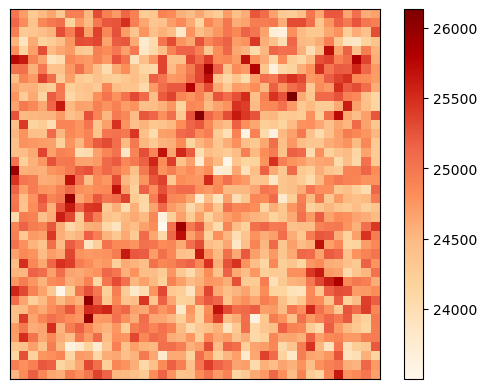

Unraveling neurons...
Done.
simulating scale-invariant case
End init
Found.
Printing image...


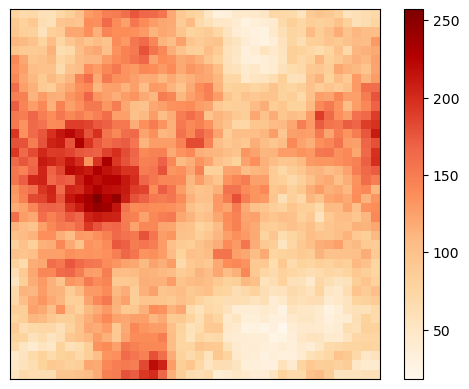

Unraveling neurons...
Done.


In [3]:
# import
from PRR2020_models.lib import contact_process as cp
import matplotlib.pyplot as plt

# simulation setup
L = 40
lag = 200
Nsamples = 40000


# ----------------------------
# (Supercritical): sustained, 
# widespread activity.
trivial_lambda = 3  
# ----------------------------

# ----------------------------
# (Critical): phase transition point, 
# with scale-invariant dynamics.
scale_invariant_lambda = 1.6488 
# ----------------------------

# simulations 
print('simulating trivial case')
states_list, real_time = cp.find_avalanche(L, Nsamples*lag, trivial_lambda, lag)
trivial_timeseries = cp.linearize_lattice(states_list).T

print('simulating scale-invariant case')
Nsamples = 2000 #reducing the number of samples to speed up the simulation
states_list, real_time = cp.find_avalanche(L, Nsamples*lag, scale_invariant_lambda, lag)
scale_invariant_timeseries = cp.linearize_lattice(states_list).T

### Use the PRG toolbox

With the dataset generated, we can now initialize the Phenomenological Renormalization Group (PRG) pipeline. 

This section feeds our simulated network activity (timeseries) directly into the toolbox. The PRG algorithm will recursively coarse-grain the data, grouping correlated variables to observe the system at each iteration. By analyzing how the statistical properties "flow" across these different scales, the observables will reveal whether the underlying dynamics exhibit the scale-invariant properties characteristic of a critical phase transition.

For this illustration, we will use the simplest pipeline (``run_PRG``) and call plots line by line, comparing some scaling exponents and distributions from the two different dynamical regimes simulated. 

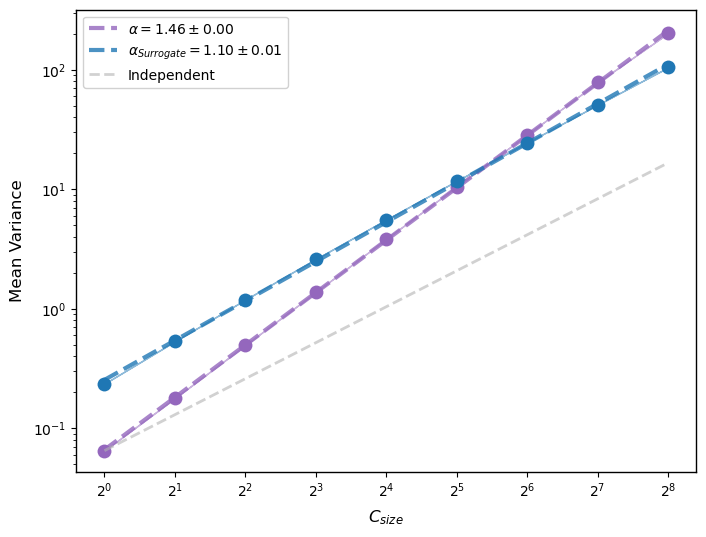

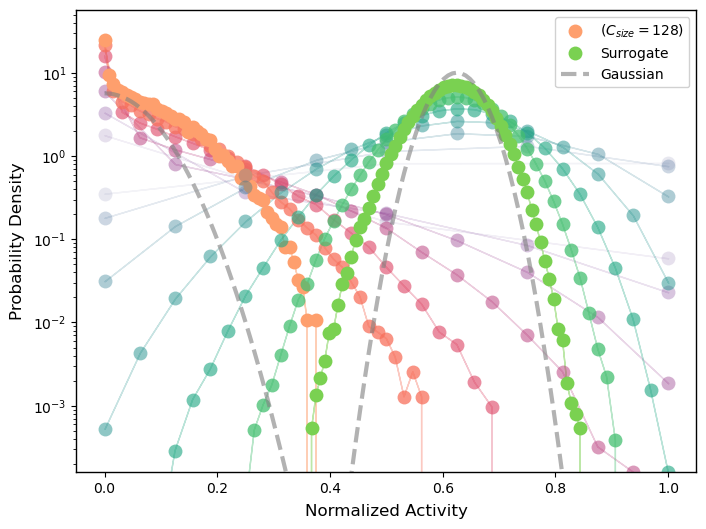

In [ ]:
import prg_toolbox as prg
import matplotlib.pyplot as plt
'''
prg_toolbox.config.AnalysisParams() loads all the default 
configurations necessary to run the toolbox.
'''
prg_params = prg.config.AnalysisParams()

'''
We can then change only the parameters we wish to change
'''
prg_params.rg_steps = 8
prg_params.observables = [prg.mean_variance, prg.activity_distribution]

'''
The `plot_style` object accepts  
'''
prg_params.plot_style.plot_kwargs = {"marker":"o","markersize":10}

results = prg.run_PRG(scale_invariant_timeseries, user_params=prg_params)

results_trivial = prg.run_PRG(trivial_timeseries, user_params=prg_params)

fig = plt.figure(figsize=(8,6))
prg.plot.plot_mean_variance(results['mean_variance'], surrogate_data=results_trivial['mean_variance'], style_config=prg_params)

fig = plt.figure(figsize=(8,6))
prg.plot.plot_activity_distribution(results['activity_distribution'], surrogate_data=results_trivial['activity_distribution'], style_config=prg_params)